# 顧客育成分析

## 目的
**顧客の利用回数の上昇**

**RFM分析を使って顧客をランク分けし、どの顧客層を育成すると利益向上につながるかを調べる。**

## 使用ライブラリ
- SQL(Bigquery)
- Python
- pandas
- matplotlib
- seaborn

## 分析内容
1. RFM分析による顧客ランクと購買傾向
2. frequency=1の顧客の特徴
3. 年代・性別と顧客ランクの関係
4. 顧客ランクごとの利益差
5. 顧客ランクごとの購入カテゴリ
6. 施策としてどの顧客層を狙うべきか


### 前準備
- ライブラリのインポート
- csvファイルの読み込み
- DataFrameの中身確認

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\RFM_data.csv")
df_category = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\user_category.csv")
df_category_rate = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\profit_rate.csv")

In [2]:
df.head()

,user_id,gender,age,first_purchase_date,last_purchase_date,recency,frequency,monetary,total_profit,avg_profit,avg_price
0,58307,M,30,2023-08-16,2024-04-29,769,2,1527.480003,887.365212,177.473042,305.496001
1,44879,F,33,2025-05-22,2025-11-29,190,2,1483.940001,761.814471,95.226809,185.492500
2,79661,M,38,2021-11-13,2025-03-22,442,2,1449.979998,795.677587,132.612931,241.663333
3,44644,F,56,2026-04-24,2026-06-01,6,4,1440.090012,753.231004,75.323100,144.009001
4,82375,M,68,2024-02-08,2026-01-17,141,3,1358.509996,741.256246,123.542708,226.418333


In [3]:
df_category.head()

,id,category,order_count,f0_,total_profit
0,58938,Clothing Sets,1,34.500000,13.489500
1,96886,Jumpsuits & Rompers,1,64.519997,28.517839
2,74214,Jumpsuits & Rompers,1,38.240002,18.737601
3,58629,Jumpsuits & Rompers,1,43.470001,18.952920
4,73277,Clothing Sets,1,59.000000,20.060000


## 1.RFM分析による顧客ランクと購買傾向

In [4]:
df[["recency", "frequency", "monetary"]].describe()

,recency,frequency,monetary
count,53113.000000,53113.000000,53113.000000
mean,603.659048,1.301263,113.322808
std,570.328395,0.592106,120.306645
min,0.000000,1.000000,1.500000
25%,142.000000,1.000000,36.000000
50%,422.000000,1.000000,73.070002
75%,921.000000,1.000000,149.500000
max,2692.000000,4.000000,1527.480003


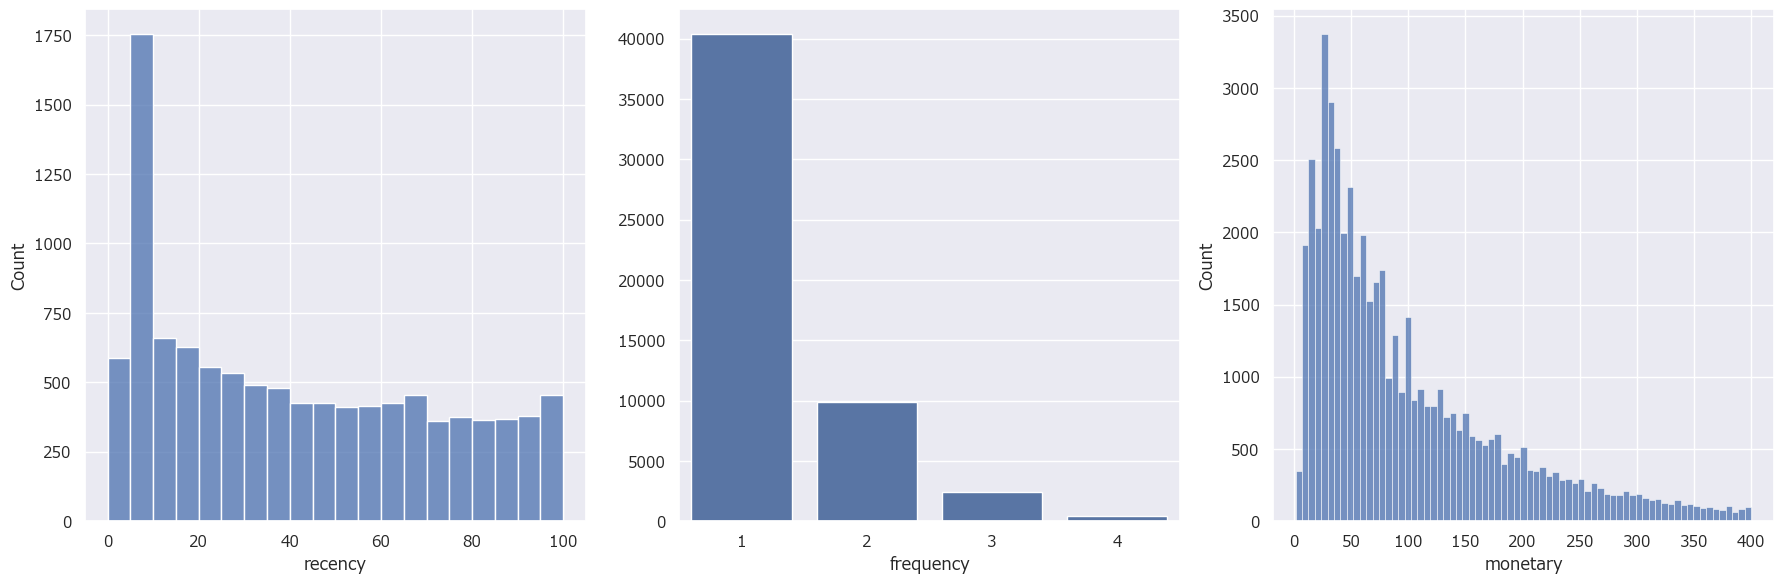

frequency
1    40400
2     9857
3     2424
4      432
Name: count, dtype: int64
一回購入者の割合：76.1%


In [5]:
freq_count = (
    df["frequency"]
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(
    data = df[df["recency"] <= 100],
    x = "recency",
    ax=axes[0]
)
sns.barplot(
    x=freq_count.index,
    y=freq_count.values,
    ax=axes[1]
)
sns.histplot(
    data = df[df["monetary"] <= 400],
    x = "monetary",
    ax=axes[2]
)
plt.tight_layout()
plt.show()

df["frequency"].value_counts()
print(df["frequency"].value_counts())

one_time_rate = (40400 / 53113) * 100
print("一回購入者の割合：" + str(round(one_time_rate, 1)) + "%")


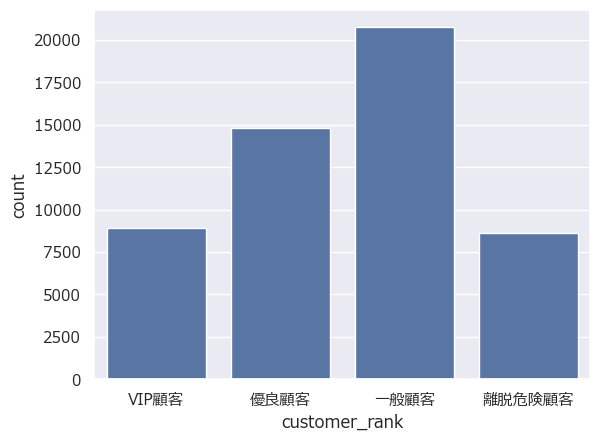

In [6]:
df["R_score"] = pd.qcut(
    df["recency"],
    4,
    labels=[4, 3, 2, 1]
)

df["F_score"] = pd.qcut(
    df["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

df["M_score"] = pd.qcut(
    df["monetary"],
    4,
    labels=[1, 2, 3, 4]
)

df["RFM_score"] = (
    df["R_score"].astype(int)
    + df["F_score"].astype(int)
    + df["M_score"].astype(int)
)

def customer_rank(score):
    if score >= 10:
        return "VIP顧客"
    elif score >= 8:
        return "優良顧客"
    elif score >= 6:
        return "一般顧客"
    else:
        return "離脱危険顧客"

df["customer_rank"] = df["RFM_score"].apply(customer_rank)
df["customer_rank"].value_counts()

sns.countplot(
    data=df,
    x="customer_rank",
    order=[
        "VIP顧客",
        "優良顧客",
        "一般顧客",
        "離脱危険顧客"
    ]
)

plt.show()

In [7]:
print("顧客ランク別人数")
print(df.groupby("customer_rank")["user_id"].count())

print()

print("顧客ランク別 平均購入金額")
print(df.groupby("customer_rank")["monetary"].mean().sort_values(ascending=False))

print()

print("顧客ランク別 平均購入回数")
print(df.groupby("customer_rank")["frequency"].mean().sort_values(ascending=False))

顧客ランク別人数
customer_rank
VIP顧客      8910
一般顧客      20751
優良顧客      14840
離脱危険顧客     8612
Name: user_id, dtype: int64

顧客ランク別 平均購入金額
customer_rank
VIP顧客     226.068888
優良顧客      113.947441
一般顧客       89.043021
離脱危険顧客     54.102271
Name: monetary, dtype: float64

顧客ランク別 平均購入回数
customer_rank
VIP顧客     2.321886
優良顧客      1.258019
一般顧客      1.018987
離脱危険顧客    1.000000
Name: frequency, dtype: float64


In [8]:
rank_count = df["customer_rank"].value_counts()
total_count = len(df)

for rank, count in rank_count.items():
    rate = count / total_count * 100
    print(f"{rank}：{count}/{total_count} * 100 = {rate:.1f}%")

一般顧客：20751/53113 * 100 = 39.1%
優良顧客：14840/53113 * 100 = 27.9%
VIP顧客：8910/53113 * 100 = 16.8%
離脱危険顧客：8612/53113 * 100 = 16.2%


### 気づいたこと
- 1回のみの顧客割合が76.1%を占めている
- 10日以内に購入した顧客が2000人を超えている
- 優良顧客も1回のみの購入の割合が大きい
- 一般顧客と優良顧客の平均購入金額にはあまり差がない。優良顧客とＶＩＰ顧客との差は2倍ほどである。
---
### 考察
多くの顧客は初夏購入後に離脱をしているのでリピート顧客を増やすことが課題だと考える。また、76.1%と大きな割合を占めているのでこの顧客を対象に再購入率を上げることで利益拡大につながる可能性がある。


## 2 frequency=1の顧客の特徴
frecuencyが1の顧客を対象に時系列、年代、性別の観点から傾向を可視化する

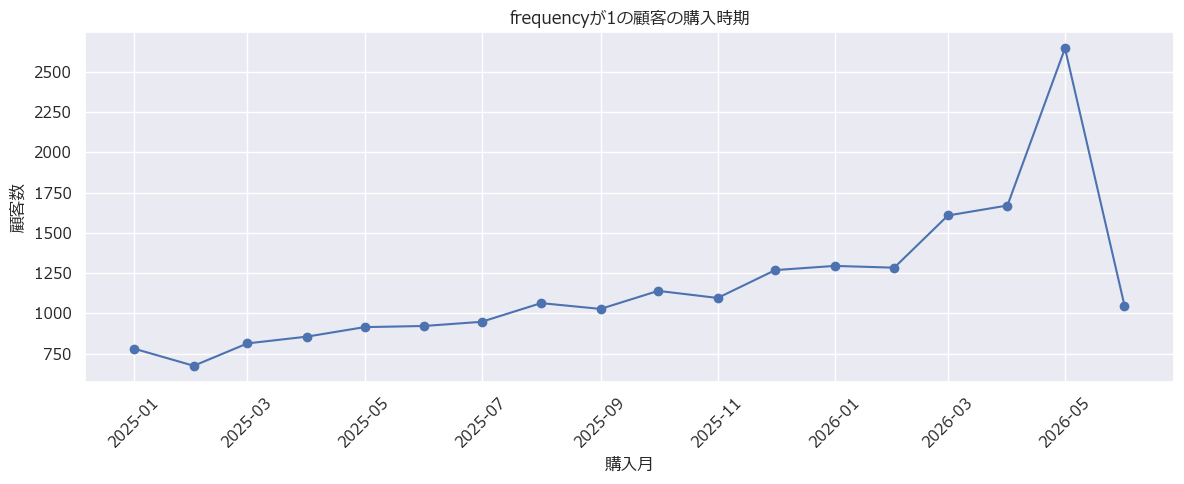

In [9]:
freq1 = df[df["frequency"] == 1].copy()

freq1["first_purchase_date"] = pd.to_datetime(freq1["first_purchase_date"])

freq1 = freq1[freq1["first_purchase_date"] >= "2025-01-01"]

freq1_monthly = (
    freq1
    .assign(purchase_month=freq1["first_purchase_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("purchase_month")
    .size()
    .reset_index(name="user_count")
)

plt.figure(figsize=(12, 5))
plt.plot(freq1_monthly["purchase_month"], freq1_monthly["user_count"], marker="o")
plt.title("frequencyが1の顧客の購入時期")
plt.xlabel("購入月")
plt.ylabel("顧客数")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 気づいたこと
- 初回購入のみの顧客は2026年5月ごろに多く分布している
---
### 考察
この顧客はリピート顧客としてのターゲットになり利益上昇に貢献する可能性がある。古参の顧客を伸ばすより、母数で考えると新規顧客の中の優良顧客もしくは一般顧客に対して、施策を打つことが重要である可能性あり。

In [10]:
rm_df = df[df["frequency"] == 1].copy()

rm_df["R_score"] = pd.qcut(
    rm_df["recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

rm_df["M_score"] = pd.qcut(
    rm_df["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

rm_df["RM_score"] = (
    rm_df["R_score"].astype(int) +
    rm_df["M_score"].astype(int)
)

rm_df["rm_rank"] = pd.cut(
    rm_df["RM_score"],
    bins=[0, 3, 6, 8],
    labels=["低", "中", "高"],
    include_lowest=True
)

rm_df["age_group"] = pd.cut(
    rm_df["age"],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=["10代", "20代", "30代", "40代", "50代", "60代以上"],
    right=False
)

print(rm_df["rm_rank"].value_counts())

pd.crosstab(
    rm_df["rm_rank"],
    rm_df["age_group"]
)

rm_rank
中    25299
低     7587
高     7514
Name: count, dtype: int64


age_group,10代,20代,30代,40代,50代,60代以上
rm_rank,,,,,,
低,982,1260,1331,1293,1319,1402
中,3432,4234,4299,4216,4347,4771
高,1059,1330,1244,1220,1230,1431


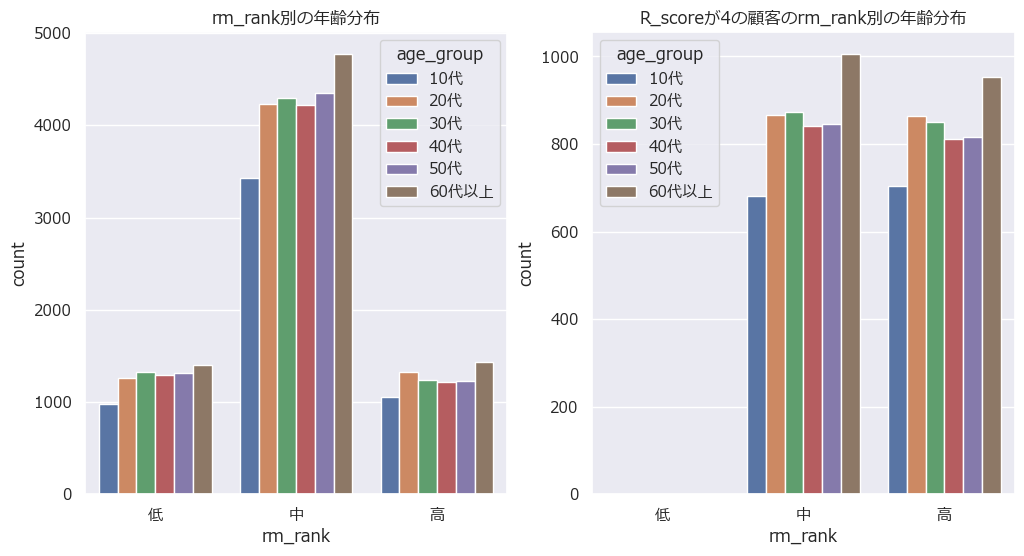

In [11]:
r4_df = rm_df[rm_df["R_score"].astype(int) == 4].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(
    data=rm_df,
    x="rm_rank",
    hue = "age_group",
    order=["低", "中", "高"],
    ax=axes[0]
)
axes[0].set_title("rm_rank別の年齢分布")

sns.countplot(
    data=r4_df,
    x="rm_rank",
    hue = "age_group",
    order=["低", "中", "高"],
    ax=axes[1]
)
axes[1].set_title("R_scoreが4の顧客のrm_rank別の年齢分布")

plt.show()

### 結果
- frequency = 1、recency = 4に条件を絞りランク分けしたところ、それぞれのランクの人数にあまり差がなかったがその中にもRMランクが高い顧客も7514人存在する
- 60代以上の人数が他と比べて多い。
- 10代は人数が少ない。
---
### 考察
rmランクが中の顧客を対象にすることで、母数が大きいため施策が当たりやすい。また、最近初回購入をした顧客の中ではm=1,2の場合とm=3,4の場合で人数はあまり変わらないため、rm_rankが高の顧客に対して施策を打つことで利益が拡大する可能性がある。高に分類される顧客に対しては、クロスセルを提示することで利益を伸ばす方が利益が上がりやすい可能性。

## 3.年代・性別と顧客ランクの関係

In [12]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,20,30,40,50,60,100],
    labels=["10代","20代","30代","40代","50代","60代以上"],
    right=False
)
pd.crosstab(
    df["customer_rank"],
    df["age_group"]
)

age_group,10代,20代,30代,40代,50代,60代以上
customer_rank,,,,,,
VIP顧客,1205,1523,1559,1504,1478,1641
一般顧客,2820,3504,3482,3459,3630,3856
優良顧客,2072,2493,2510,2431,2478,2856
離脱危険顧客,1150,1448,1519,1463,1424,1608


In [13]:
pd.crosstab(
    df["customer_rank"],
    df["age_group"],
    normalize="index"
) * 100

age_group,10代,20代,30代,40代,50代,60代以上
customer_rank,,,,,,
VIP顧客,13.524130,17.093154,17.497194,16.879910,16.588103,18.417508
一般顧客,13.589707,16.885933,16.779914,16.669076,17.493133,18.582237
優良顧客,13.962264,16.799191,16.913747,16.381402,16.698113,19.245283
離脱危険顧客,13.353460,16.813748,17.638179,16.987924,16.535067,18.671621


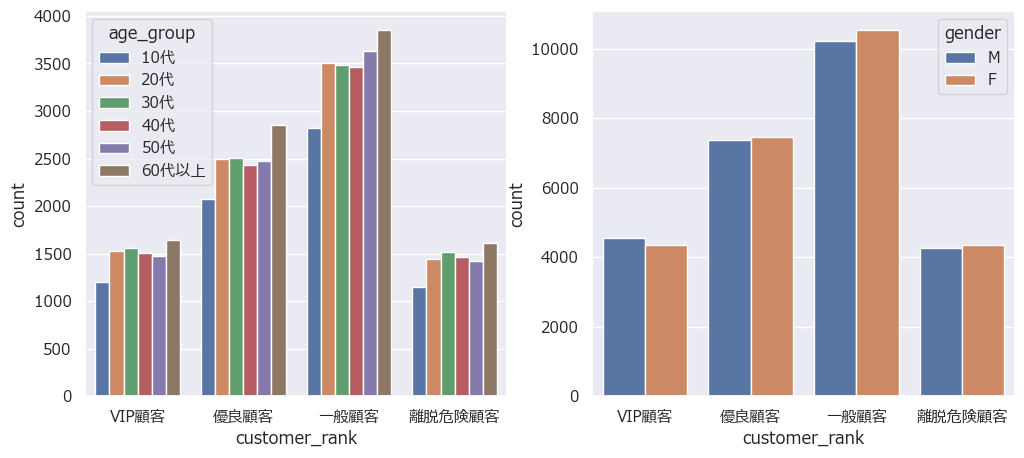

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.countplot(
    data=df,
    x="customer_rank",
    hue="age_group",
    ax=axes[0]
)
sns.countplot(
    data=df,
    x = "customer_rank",
    hue="gender",
    ax=axes[1]
)
plt.show()

### 気づいたこと
- 顧客ランクごとの男女の人数差は少ないが、一般顧客の人数が多い
---
### 考察
60代はどのランク帯にも多いので60代をターゲットとした施策を充てることで利益拡大を狙える可能性あり。

## 顧客ランクごとの利益差

In [17]:
rank_profit = df.groupby("customer_rank").agg(
    user_count=("user_id", "nunique"),
    total_profit=("total_profit", "sum"),
    avg_profit_per_user=("total_profit", "mean")
).reset_index()

rank_profit

,customer_rank,user_count,total_profit,avg_profit_per_user
0,VIP顧客,8910,1.047802e+06,117.598460
1,一般顧客,20751,9.608343e+05,46.303038
2,優良顧客,14840,8.789269e+05,59.226878
3,離脱危険顧客,8612,2.377230e+05,27.603688


In [19]:
# ランクアップした場合の利益の理論値
avg_general = rank_profit.loc[
    rank_profit["customer_rank"] == "一般顧客",
    "avg_profit_per_user"
].iloc[0]

avg_good = rank_profit.loc[
    rank_profit["customer_rank"] == "優良顧客",
    "avg_profit_per_user"
].iloc[0]

avg_vip = rank_profit.loc[
    rank_profit["customer_rank"] == "VIP顧客",
    "avg_profit_per_user"
].iloc[0]

general_to_good_profit = avg_good - avg_general
good_to_vip_profit = avg_vip - avg_good

print("一般顧客 → 優良顧客 の1人あたり利益増加:", general_to_good_profit)
print("優良顧客 → VIP顧客 の1人あたり利益増加:", good_to_vip_profit)

一般顧客 → 優良顧客 の1人あたり利益増加: 12.923840254647217
優良顧客 → VIP顧客 の1人あたり利益増加: 58.37158118164843


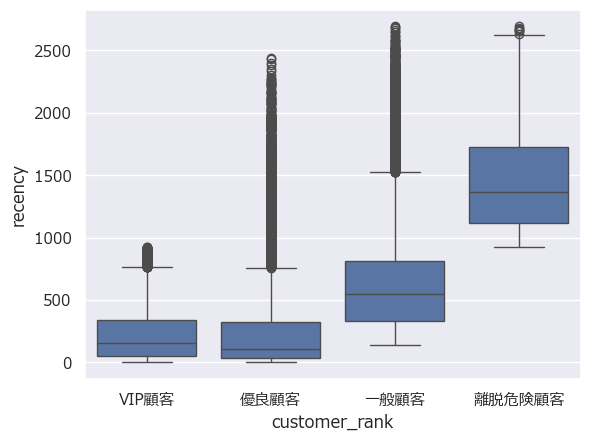

                 count         mean         std    min     25%     50%     75%     max
customer_rank                                                                         
VIP顧客           8910.0   228.695847  220.771051    1.0    55.0   156.0   339.0   921.0
一般顧客           20751.0   649.162643  436.128167  143.0   334.0   552.0   811.0  2692.0
優良顧客           14840.0   269.910984  389.507642    0.0    37.0   105.0   326.0  2437.0
離脱危険顧客          8612.0  1457.061078  406.494988  922.0  1119.0  1368.0  1724.0  2692.0


In [27]:
sns.boxplot(
    data=df,
    x="customer_rank",
    y="recency"
)
plt.show()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df.groupby("customer_rank")["recency"].describe())

### 気づいたこと
- 一般顧客と優良顧客の平均利益の差が少なく、優良顧客とVIP顧客の平均利益は2倍程差がある。
- VIP顧客よりも優良顧客の方がrecencyが高い

**理論値** 
- 一般顧客 → 優良顧客 の1人あたり利益増加: 12.923840254647217
- 優良顧客 → VIP顧客 の1人あたり利益増加: 58.37158118164843

---
### 考察
recencyがＶＩＰより優良の方が小さいことから、優良顧客をＶＩＰ顧客にランクアップさせる施策を行うことで利益増加が見込める可能性あり。今回期待値の数値を出すことはできないため、本報告書には記載しないが、一般顧客と優良顧客の母数と、recencyを見る限り利益を上げやすいのは優良顧客からＶＩＰ顧客にランクアップする場合であると考える。

## 顧客ランクごとの購入カテゴリ

In [44]:
df_category_rate.sort_values("total_profit", ascending=False)

,category,total_price,total_profit,profit_rate
21,Outerwear & Coats,1.320863e+06,734097.950702,55.577154
15,Jeans,1.257691e+06,585103.738642,46.522062
13,Sweaters,8.318446e+05,431718.650325,51.898956
18,Suits & Sport Coats,6.676659e+05,399726.640370,59.869257
2,Swim,6.423847e+05,315499.167913,49.113742
8,Fashion Hoodies & Sweatshirts,6.329907e+05,304617.626158,48.123558
17,Sleep & Lounge,5.420984e+05,281259.342568,51.883448
3,Active,4.648803e+05,269688.208766,58.012394
6,Dresses,4.737604e+05,260438.030880,54.972526
14,Shorts,5.149121e+05,257023.359580,49.915972


In [28]:
df_merge = df.merge(
    df_category,
    left_on="user_id",
    right_on="id",
    how="left"
)

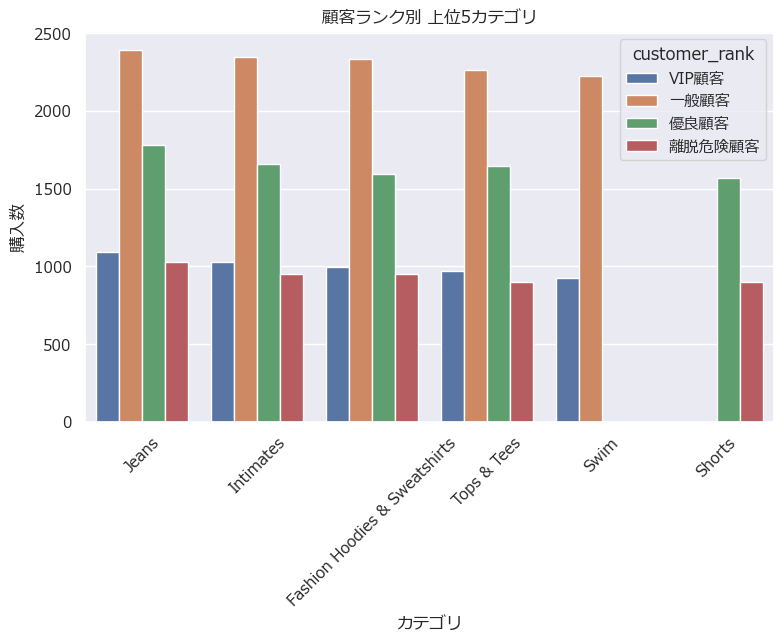

In [38]:
top_category = (
    df_merge
    .groupby(["customer_rank", "category"])
    .size()
    .reset_index(name="count")
    .sort_values(["customer_rank", "count"], ascending=[True, False])
    .groupby("customer_rank")
    .head(5)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_category,
    x="category",
    y="count",
    hue="customer_rank"
)

plt.title("顧客ランク別 上位5カテゴリ")
plt.xlabel("カテゴリ")
plt.ylabel("購入数")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [37]:
graph_categories = [
    "Jeans",
    "Intimates",
    "Fashion Hoodies & Sweatshirts",
    "Tops & Tees",
    "Swim",
    "Shorts"
]

df_category_rate_graph = df_category_rate[
    df_category_rate["category"].isin(graph_categories)
]

print(df_category_rate_graph)
print()
print("全カテゴリ平均利益率：" + str(df_category_rate["profit_rate"].mean()))

                         category   total_price   total_profit  profit_rate
2                            Swim  6.423847e+05  315499.167913    49.113742
8   Fashion Hoodies & Sweatshirts  6.329907e+05  304617.626158    48.123558
12                    Tops & Tees  4.885177e+05  214970.143770    44.004581
14                         Shorts  5.149121e+05  257023.359580    49.915972
15                          Jeans  1.257691e+06  585103.738642    46.522062
20                      Intimates  4.601282e+05  214983.273274    46.722470

全カテゴリ平均利益率：50.878253415324316


In [47]:
user_category = pd.crosstab(
    df_merge["user_id"],
    df_merge["category"]
)

cross_sell_users = user_category[
    (user_category["Jeans"] > 0) &
    (user_category["Intimates"] > 0)
]

cross_sell_user_count = len(cross_sell_users)

jeans_users = user_category[user_category["Jeans"] > 0]
intimates_users = user_category[user_category["Intimates"] > 0]

jeans_user_count = len(jeans_users)
intimates_user_count = len(intimates_users)

cross_sell_rate_from_jeans = cross_sell_user_count / jeans_user_count * 100
cross_sell_rate_from_intimates = cross_sell_user_count / intimates_user_count * 100

print("Jeans購入者数:", jeans_user_count)
print("Intimates購入者数:", intimates_user_count)
print("両方購入者数:", cross_sell_user_count)
print(f"Jeans購入者のうちIntimatesも購入: {cross_sell_rate_from_jeans:.1f}%")
print(f"Intimates購入者のうちJeansも購入: {cross_sell_rate_from_intimates:.1f}%")

Jeans購入者数: 6289
Intimates購入者数: 5989
両方購入者数: 700
Jeans購入者のうちIntimatesも購入: 11.1%
Intimates購入者のうちJeansも購入: 11.7%


### 気づいたこと
- 購入数が多いカテゴリはどれも平均利益率を下回っている。
- JeansやFashon Hoodies ＆Sweatershirtsは売上がよく施策の対象となりうる。
- Swimはtotal_priceは高いが、優良顧客ではなく、一般顧客を対象にする施策になる
---
### 考察
優良顧客に対しては、JeansやFashon Hoodies ＆Sweatershirtsの二つの商品を中心に施策を考える。

## 施策提案

**施策①：クーポンの配布**
- ターゲット：顧客全体
- 内容：VIP顧客に対して、高額商品の値段を10%offにするクーポンを配布。優良顧客に対しては、セット割で安くなるクーポンを配布。一般顧客に対しては、次回来店時に全商品対象のクーポン券を配布する。

- 期待効果：リピート率向上

**施策②：クロスセル施策**
- ターゲット：Frequency=1、RMランク上位顧客
- 内容：目当ての商品や高額な商品に合うような商品を同時に購入させる。
- 期待効果：購入カテゴリ数増加

**施策③：60代向けメールマーケティング**
- ターゲット：60代
- 内容：シニア向け特集の作成
- 期待効果：シニアの高額商品購入、リピート率の向上